IMPORTING LIBRARIES


In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, roc_curve, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
df=pd.read_csv('loan_data.csv')
df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


DATA CLEANING-> DESCRIPTION, DUPLICATE VALUES, CHECKING SKEWED DATA AND FIXING IT

In [3]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

In [4]:
print(df.isnull().sum(),'\n')
print(df.duplicated().sum(),'\n')
print(df.value_counts(),'\n')

person_age                        0
person_gender                     0
person_education                  0
person_income                     0
person_emp_exp                    0
person_home_ownership             0
loan_amnt                         0
loan_intent                       0
loan_int_rate                     0
loan_percent_income               0
cb_person_cred_hist_length        0
credit_score                      0
previous_loan_defaults_on_file    0
loan_status                       0
dtype: int64 

0 

person_age  person_gender  person_education  person_income  person_emp_exp  person_home_ownership  loan_amnt  loan_intent        loan_int_rate  loan_percent_income  cb_person_cred_hist_length  credit_score  previous_loan_defaults_on_file  loan_status
144.0       male           Bachelor          300616.0       125             RENT                   4800.0     VENTURE            13.57          0.02                 3.0                         789           No                 

In [5]:
print(df.dtypes,'\n')
print(df.nunique(),'\n')
for column in df.columns:
    if df[column].dtype==object:
        print(df[column].unique(),'for', column)

person_age                        float64
person_gender                      object
person_education                   object
person_income                     float64
person_emp_exp                      int64
person_home_ownership              object
loan_amnt                         float64
loan_intent                        object
loan_int_rate                     float64
loan_percent_income               float64
cb_person_cred_hist_length        float64
credit_score                        int64
previous_loan_defaults_on_file     object
loan_status                         int64
dtype: object 

person_age                           60
person_gender                         2
person_education                      5
person_income                     33989
person_emp_exp                       63
person_home_ownership                 4
loan_amnt                          4483
loan_intent                           6
loan_int_rate                      1302
loan_percent_income                 

In [6]:
# from sklearn.preprocessing import PowerTransformer
# pt=PowerTransformer(method='yeo-johnson')
num_cols=df.select_dtypes(include=['int64', 'float64']).columns
num_cols = num_cols.drop('loan_status')  
df[num_cols].skew()
# for column in num_cols:
#     if df[column].skew()>0.5 and df[column].skew()<1:
#         df[column]=np.sqrt(df[column])
#     elif df[column].skew()>=1:
#         df[column]=np.log1p(df[column])
#     elif df[column].skew()>=-1 and df[column].skew()<0.5:
#         df[column]=np.cbrt(-df[column])
#     elif df[column].skew()<=-1:
#         df[[column]]=pt.fit_transform(df[[column]])
# df.head()


person_age                     2.548154
person_income                 34.137583
person_emp_exp                 2.594917
loan_amnt                      1.179731
loan_int_rate                  0.213784
loan_percent_income            1.034512
cb_person_cred_hist_length     1.631720
credit_score                  -0.610261
dtype: float64

VISUALIZING THE COLUMNS

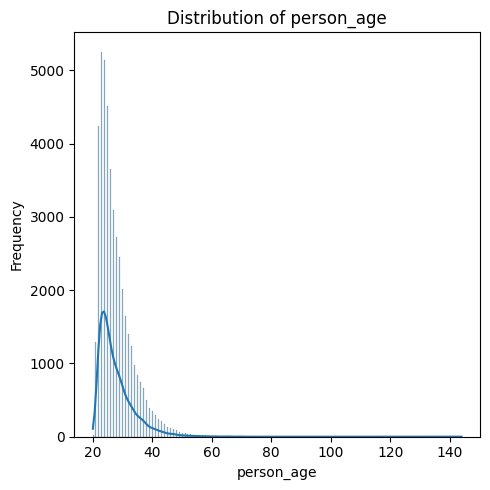

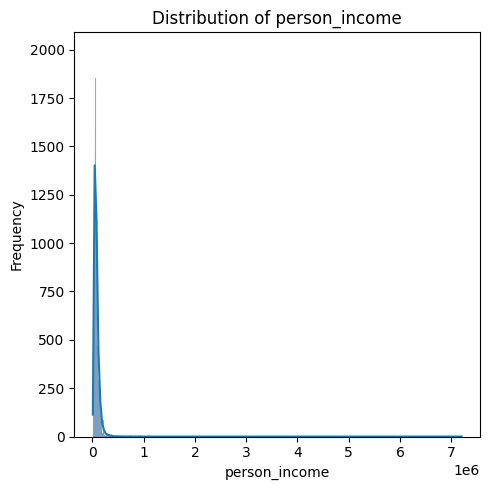

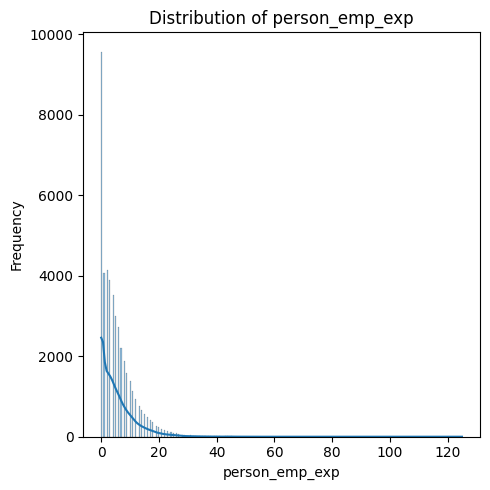

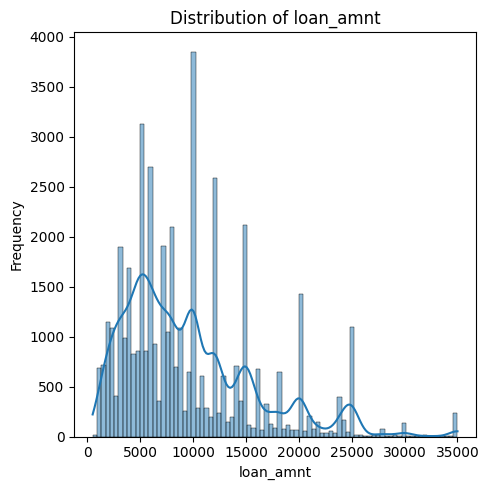

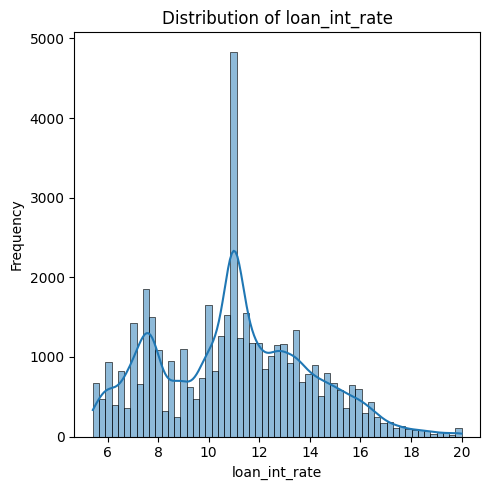

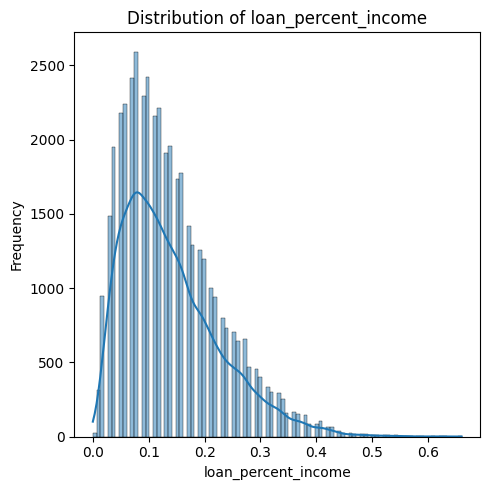

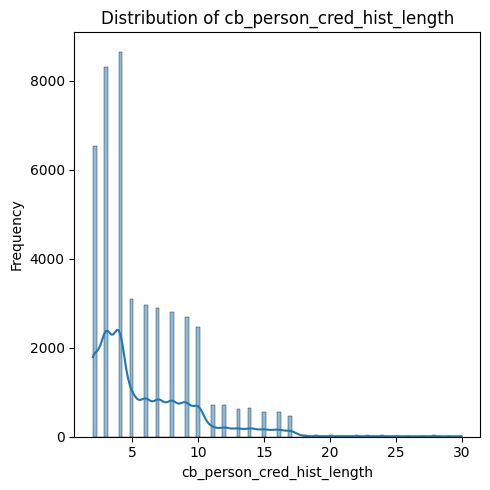

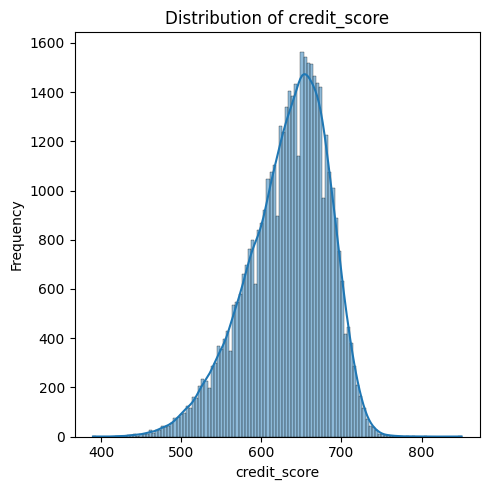

In [7]:
for column in num_cols:
    plt.figure(figsize=(5, 5))
    sns.histplot(df[column],kde=True)
    plt.title(f'Distribution of {column}')
    plt.xlabel(column)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

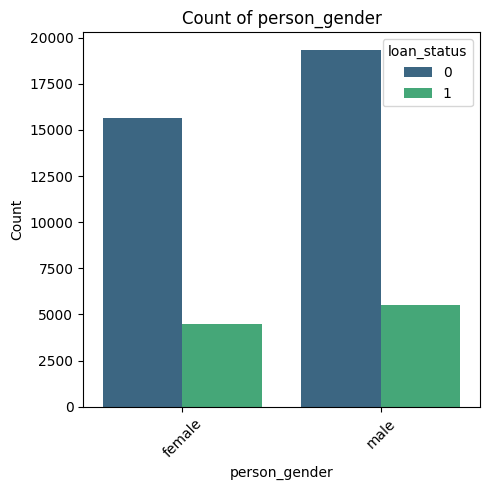

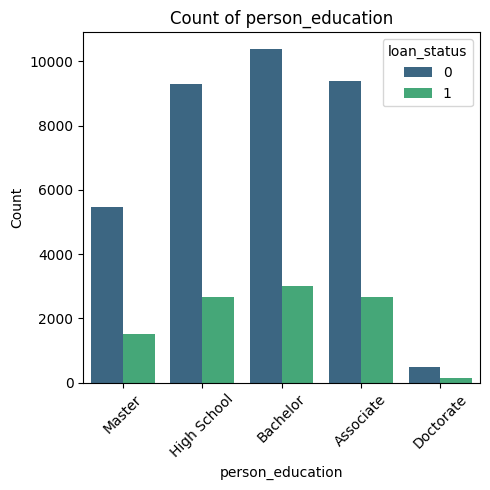

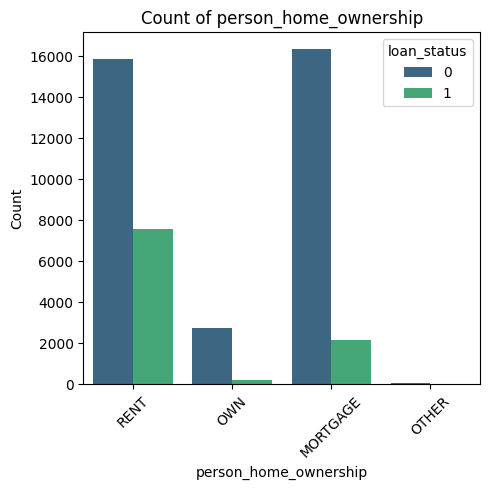

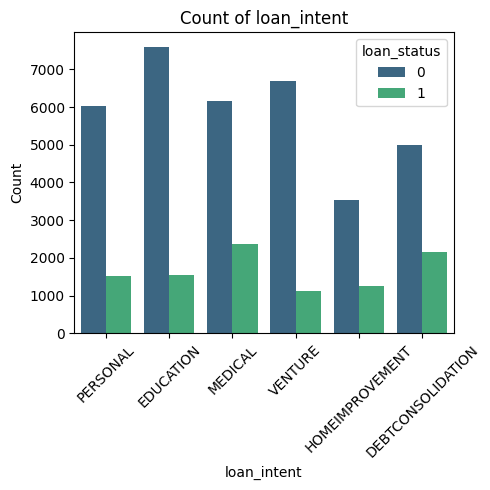

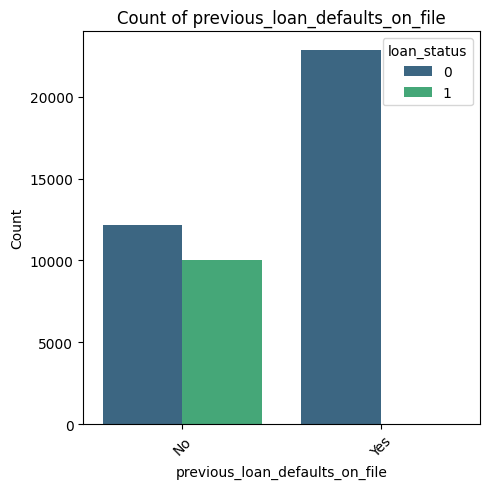

In [8]:
object_cols=df.select_dtypes(include=['object']).columns
for column in object_cols:
    plt.figure(figsize=(5, 5))
    sns.countplot(x=df[column], palette='viridis',hue=df['loan_status'])
    plt.title(f'Count of {column}')
    plt.xlabel(column)
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

SWITCHING OBJECT VALUES FOR NUMERICAL VALUES 

In [9]:
# df['person_gender']=df['person_gender'].map({'male':0, 'female':1}).fillna(2)
# df['person_education']=df['person_education'].map({'High School':0, 'Bachelor':1, 'Master':2, 'PhD':3}).fillna(4)
# df['person_home_ownership']=df['person_home_ownership'].map({'RENT':0, 'OWN':1, 'MORTGAGE':2}).fillna(3)
# df['loan_intent']=df['loan_intent'].map({'PERSONAL':0, 'BUSINESS':1, 'EDUCATION':2, 'MEDICAL':3}).fillna(4)
# df['previous_loan_defaults_on_file']=df['previous_loan_defaults_on_file'].map({'No':0, 'Yes':1}).fillna(2)
# df.head()
# from sklearn.preprocessing import LabelEncoder
# cat_cols=object_cols.drop('previous_loan_defaults_on_file')
# label_encoders={}
# for col in cat_cols:
#     le=LabelEncoder()
#     df[col]=le.fit_transform(df[col])
#     label_encoders[col]=le.classes_
# df.head()
# for col,classes in label_encoders.items():
#     print(f'Classes for {col}:')
#     for i,label in enumerate(classes):
#         print(f'{i}: {label}')
df['previous_loan_defaults_on_file']=(df['previous_loan_defaults_on_file'].replace({'No':0,'Yes':1}).fillna(2).astype(int))


C:\Users\Rishi\AppData\Local\Temp\ipykernel_2064\3782461692.py:19: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['previous_loan_defaults_on_file']=(df['previous_loan_defaults_on_file'].replace({'No':0,'Yes':1}).fillna(2).astype(int))


ADDING SOME RATIOS FROM THE GIVEN DATA AND PLOTTING A HEATMAP OF CORRELATIONS

In [10]:
df['debt_burden_score']=df['loan_percent_income']/df['loan_int_rate']  #Debt burden score- how easy it will be for a borrower to repay..
                                                                            #..their loan
df['income_per_year_exp']=np.where(
    df['person_emp_exp']!=0,
    df['person_income']/df['person_emp_exp'],
    df['person_income']
)        #Income per year of experience

df['credit_age_score']=df['credit_score']/df['cb_person_cred_hist_length']  #Kind of normalizes the credit score
df=df[[col for col in df.columns if col!= 'loan_status']+['loan_status']]
df.drop(columns='person_gender',inplace=True)
df.head()

,person_age,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,debt_burden_score,income_per_year_exp,credit_age_score,loan_status
0,22.0,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,0,0.030587,71948.0,187.000000,1
1,21.0,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,1,0.007181,12282.0,252.000000,0
2,25.0,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,0,0.034188,4146.0,211.666667,1
3,23.0,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,0,0.028890,79753.0,337.500000,1
4,24.0,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,0,0.037141,66135.0,146.500000,1


<Axes: >

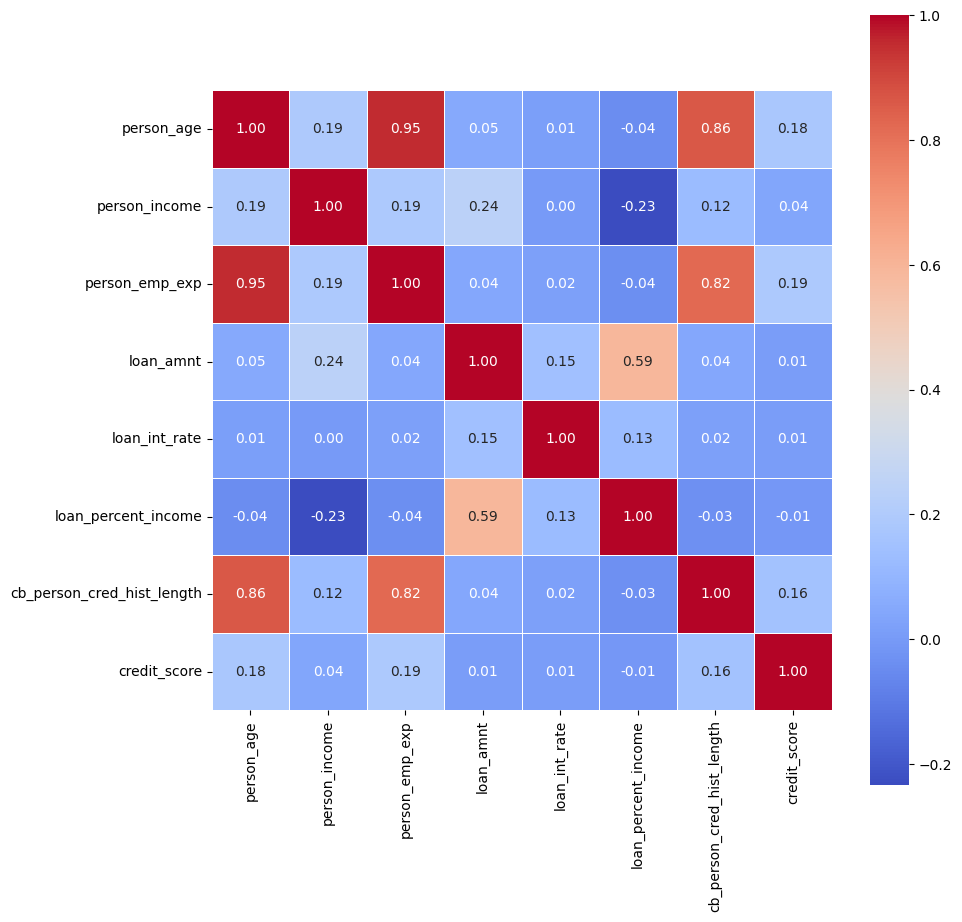

In [11]:
plt.figure(figsize=(10, 10))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm',fmt='.2f',square=True, linewidths=0.5) 

TRAIN-TEST SPLIT

In [12]:
df_encoded = pd.get_dummies(df.drop('loan_status', axis=1), drop_first=True)
X_train, X_test, y_train, y_test = train_test_split(df_encoded, df['loan_status'], test_size=0.2)

In [13]:
df_encoded.head()

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,debt_burden_score,...,person_education_High School,person_education_Master,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE
0,22.0,71948.0,0,35000.0,16.02,0.49,3.0,561,0,0.030587,...,False,True,False,False,True,False,False,False,True,False
1,21.0,12282.0,0,1000.0,11.14,0.08,2.0,504,1,0.007181,...,True,False,False,True,False,True,False,False,False,False
2,25.0,12438.0,3,5500.0,12.87,0.44,3.0,635,0,0.034188,...,True,False,False,False,False,False,False,True,False,False
3,23.0,79753.0,0,35000.0,15.23,0.44,2.0,675,0,0.028890,...,False,False,False,False,True,False,False,True,False,False
4,24.0,66135.0,1,35000.0,14.27,0.53,4.0,586,0,0.037141,...,False,True,False,False,True,False,False,True,False,False


RANDOM FOREST MODEL

In [14]:
from scipy.stats import randint
import joblib
param_grid={
    'n_estimators':randint(150,200),
    'max_depth':[None]+list(range(5,30,5)),
    'min_samples_split': randint(2, 10),
    'min_samples_leaf': randint(1,10),
    'criterion': ['entropy'],
    'bootstrap':[True, False]
}
rf=RandomForestClassifier(random_state=0, class_weight='balanced')
model=RandomizedSearchCV(estimator=rf, param_distributions=param_grid, n_iter=100, cv=5, scoring='accuracy', n_jobs=-1, random_state=42)
model.fit(X_train, y_train)
# print(model.best_score_)
print('Best parameters found:', model.best_params_)


random_forest_predict=model.predict(X_test)
random_forest_conf_matrix=confusion_matrix(y_test, random_forest_predict)
random_forest_acc_score=accuracy_score(y_test, random_forest_predict)
print('Model training data score is:', str(model.score(X_train, y_train)*100) +'%')
print('Model score is:',str(model.score(X_test, y_test)*100) +'%')
print('confusion matrix:')
print(random_forest_conf_matrix,'\n')
print('accuracy score:')
print(random_forest_acc_score*100,'\n')
print(classification_report(y_test, random_forest_predict))
joblib.dump(model.best_estimator_, 'best_random_forest.pkl')

Best parameters found: {'bootstrap': True, 'criterion': 'entropy', 'max_depth': 25, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 176}
Model training data score is: 100.0%
Model score is: 93.07777777777778%
confusion matrix:
[[6850  176]
 [ 447 1527]] 

accuracy score:
93.07777777777778 

              precision    recall  f1-score   support

           0       0.94      0.97      0.96      7026
           1       0.90      0.77      0.83      1974

    accuracy                           0.93      9000
   macro avg       0.92      0.87      0.89      9000
weighted avg       0.93      0.93      0.93      9000



['best_random_forest.pkl']

    importance                        features
16    0.000337     person_home_ownership_OTHER
13    0.000806      person_education_Doctorate
15    0.003901         person_education_Master
14    0.004662    person_education_High School
12    0.004784       person_education_Bachelor
22    0.004875            loan_intent_PERSONAL
21    0.004993             loan_intent_MEDICAL
19    0.006381           loan_intent_EDUCATION
20    0.006526     loan_intent_HOMEIMPROVEMENT
23    0.009211             loan_intent_VENTURE
17    0.010166       person_home_ownership_OWN
6     0.015911      cb_person_cred_hist_length
2     0.019400                  person_emp_exp
0     0.021271                      person_age
11    0.030876                credit_age_score
7     0.037318                    credit_score
10    0.038738             income_per_year_exp
3     0.042593                       loan_amnt
18    0.044200      person_home_ownership_RENT
9     0.061694               debt_burden_score
1     0.08500

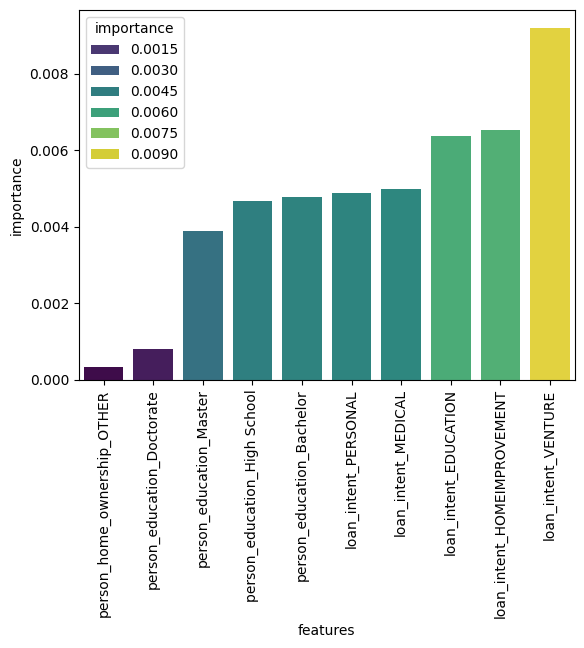

In [15]:
importances=pd.DataFrame(model.best_estimator_.feature_importances_)
importances['features']=X_train.columns
importances.columns=['importance', 'features']
importances.sort_values(by='importance',ascending=True, inplace=True)
print(importances)
sns.barplot(x=importances['features'].head(10),y=importances['importance'].head(10), palette='viridis', hue=importances['importance'].head(10))
plt.xticks(rotation=90)
plt.show()

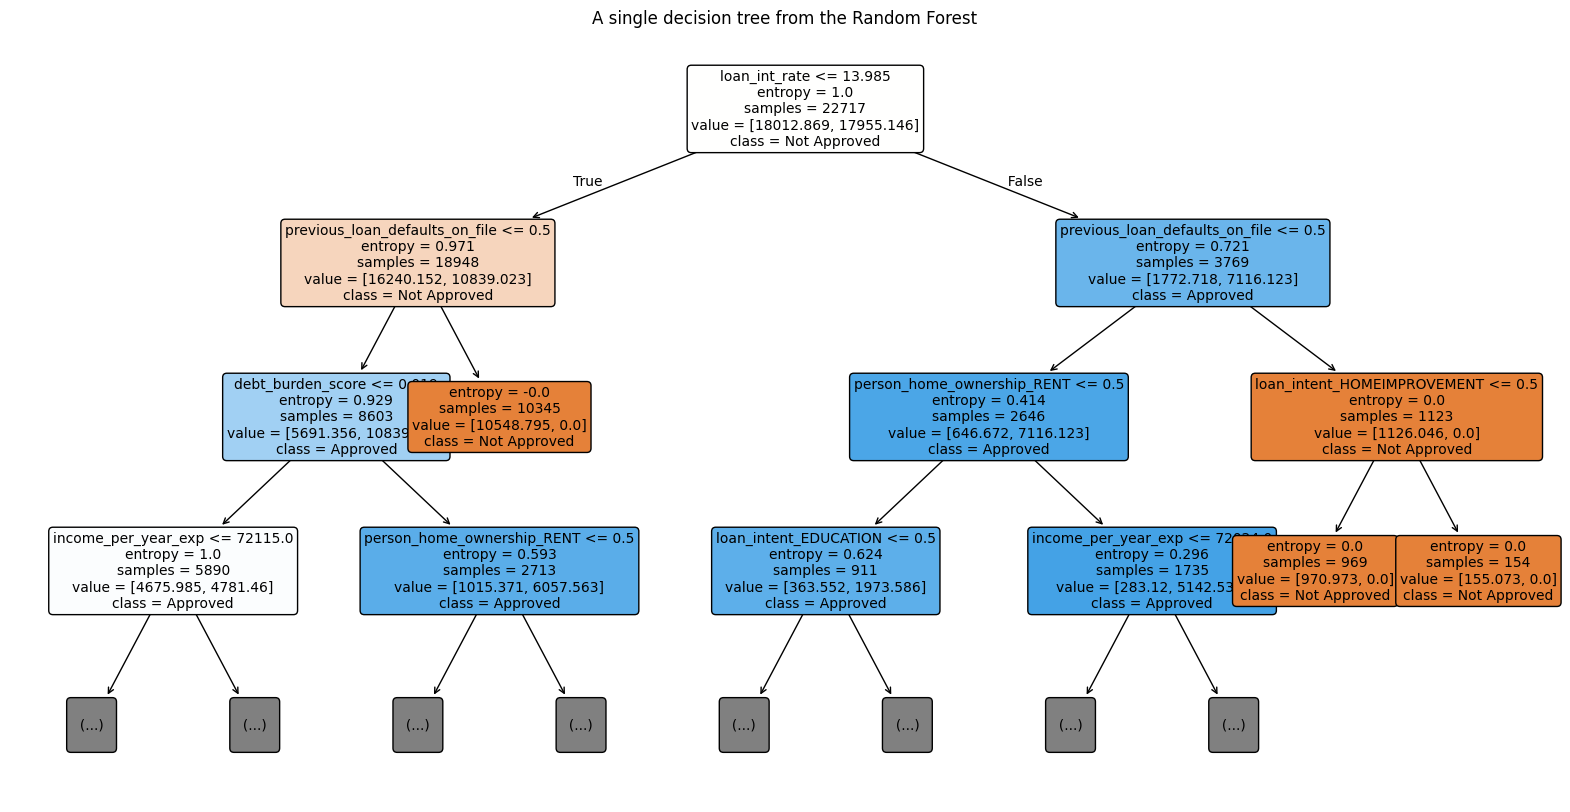

In [16]:
from sklearn.tree import plot_tree
best_rf=model.best_estimator_
onetree=best_rf.estimators_[0]
plt.figure(figsize=(20,10))
plot_tree(onetree,
          feature_names=X_train.columns,
          class_names=['Not Approved', 'Approved'],
          filled=True,
          rounded=True,
          fontsize=10,
          max_depth=3,
          proportion=False,
        #   label='root'
          )
plt.title('A single decision tree from the Random Forest')
plt.show()

XGBOOST MODEL

In [17]:
from xgboost import XGBClassifier
import optuna
from sklearn.model_selection import cross_val_score

def objective(trial):
    params={
        'n_estimators':trial.suggest_int('n_estimators', 100, 1000, step=100),
        'max_depth':trial.suggest_int('max_depth', 3, 10),
        'learning_rate':trial.suggest_float('learning_rate', 0.01, 0.3, step=0.01),
        'subsample':trial.suggest_float('subsample', 0.5, 1.0, step=0.1),
        'colsample_bytree':trial.suggest_float('colsample_bytree',0.5,1.0),
        'gamma':trial.suggest_float('gamma',0,5),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 10),
        'reg_lambda': trial.suggest_float('reg_lambda', 0, 10),
        'use_label_encoder': False,
        'eval_metric': 'logloss'
    }
    model=XGBClassifier(**params, verbosity=0)
    score=cross_val_score(model,X_train,y_train,cv=5,scoring='accuracy')
    return np.mean(score)

study=optuna.create_study(direction='maximize')
study.optimize(objective,n_trials=50)
print('Best Accuracy (CV):', study.best_value)
print('Best parameters', study.best_params)
 
best_params=study.best_params
best_params['use_label_encoder']=False
best_params['eval_metric']='logloss'

model_xgb=XGBClassifier(**best_params, random_state=42, verbosity=0)
model_xgb.fit(X_train, y_train)
print("Test Accuracy:", model_xgb.score(X_test, y_test))
y_pred=model_xgb.predict(X_test)


[I 2025-09-27 11:20:46,341] A new study created in memory with name: no-name-eeab0514-80e9-455f-b561-60167538c99c
[I 2025-09-27 11:20:56,073] Trial 0 finished with value: 0.9248333333333333 and parameters: {'n_estimators': 700, 'max_depth': 10, 'learning_rate': 0.01, 'subsample': 0.5, 'colsample_bytree': 0.5560067901103363, 'gamma': 2.4217325393751246, 'reg_alpha': 5.407348078044788, 'reg_lambda': 0.3895676065075271}. Best is trial 0 with value: 0.9248333333333333.
[I 2025-09-27 11:20:57,522] Trial 1 finished with value: 0.9223055555555556 and parameters: {'n_estimators': 100, 'max_depth': 8, 'learning_rate': 0.03, 'subsample': 0.7, 'colsample_bytree': 0.7554373132368399, 'gamma': 0.3119585392821067, 'reg_alpha': 8.582068762940656, 'reg_lambda': 9.570347408161018}. Best is trial 0 with value: 0.9248333333333333.
[I 2025-09-27 11:21:01,374] Trial 2 finished with value: 0.9286388888888888 and parameters: {'n_estimators': 600, 'max_depth': 5, 'learning_rate': 0.11, 'subsample': 0.7, 'cols

Best Accuracy (CV): 0.9317499999999999
Best parameters {'n_estimators': 600, 'max_depth': 10, 'learning_rate': 0.09, 'subsample': 0.8, 'colsample_bytree': 0.7705685222268427, 'gamma': 0.869940416453373, 'reg_alpha': 4.408954248815002, 'reg_lambda': 0.6717580319465131}
Test Accuracy: 0.9341111111111111


In [30]:
import pickle

joblib.dump(model_xgb, 'best_xgboost_model.pkl')

with open('model_columns.pkl', 'wb') as f:
    pickle.dump(X_train.columns.tolist(), f)
print(type(model_xgb), type(X_train.columns.tolist()))

<class 'xgboost.sklearn.XGBClassifier'> <class 'list'>


In [19]:
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Test Accuracy: 0.9341111111111111
Confusion Matrix:
 [[6814  212]
 [ 381 1593]]
Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.97      0.96      7026
           1       0.88      0.81      0.84      1974

    accuracy                           0.93      9000
   macro avg       0.91      0.89      0.90      9000
weighted avg       0.93      0.93      0.93      9000



In [20]:
import optuna.visualization as vis

vis.plot_optimization_history(study).show()
vis.plot_param_importances(study).show()

LOGISTIC REGRESSION

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
pipe=Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression())
])
param_grid={
    'classifier__C': [0.1, 1, 10],
    'classifier__penalty': ['l2','l1'],
    'classifier__solver': ['liblinear'] 
}
model_logreg=GridSearchCV(pipe,param_grid=param_grid,cv=5,scoring='accuracy',n_jobs=-1)
model_logreg.fit(X_train, y_train)
print('Best parameters found:', model_logreg.best_params_)
print('Best CV accuracy:', model_logreg.best_score_)

Best parameters found: {'classifier__C': 0.1, 'classifier__penalty': 'l1', 'classifier__solver': 'liblinear'}
Best CV accuracy: 0.8992777777777778


In [22]:
y_pred=model_logreg.predict(X_test)
print(model_logreg.score(X_test, y_test))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(accuracy_score(y_test, y_pred))
joblib.dump(model_logreg, 'model_logreg.pkl')

0.9037777777777778
              precision    recall  f1-score   support

           0       0.94      0.94      0.94      7026
           1       0.79      0.77      0.78      1974

    accuracy                           0.90      9000
   macro avg       0.86      0.86      0.86      9000
weighted avg       0.90      0.90      0.90      9000

[[6615  411]
 [ 455 1519]]
0.9037777777777778


['model_logreg.pkl']

<Axes: xlabel='Feature'>

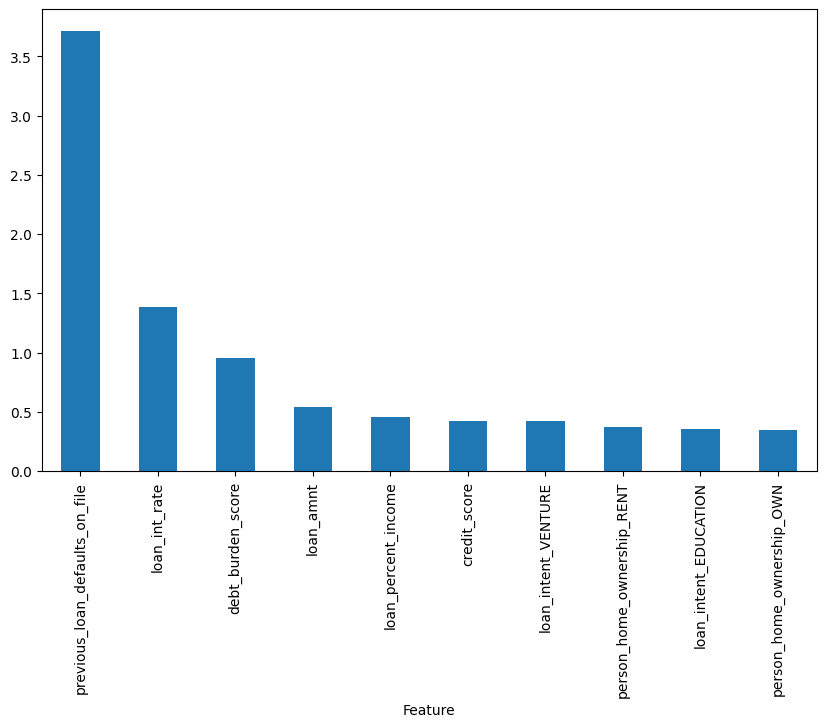

In [23]:
importance_df=pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': abs(model_logreg.best_estimator_.named_steps['classifier'].coef_[0])
}).sort_values(by='Importance', ascending=False).head(10)
importance_df.plot(kind='bar', x='Feature', y='Importance', legend=False, figsize=(10,6))

COMPARING THE THREE MODELS

In [31]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report

models = {
    "Random Forest": joblib.load('best_random_forest.pkl'),
    "XGBoost": joblib.load('best_xgboost_model.pkl'),
    "Logistic Regression": joblib.load('model_logreg.pkl')
}

for name, model in models.items():
    y_pred = model.predict(X_test)
    print(f"\n{name} Results:")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred))
    print("ROC AUC:", roc_auc_score(y_test, model.predict_proba(X_test)[:, 1]))



Random Forest Results:
Accuracy: 0.9307777777777778
Precision: 0.8966529653552554
Recall: 0.7735562310030395
F1 Score: 0.8305683981506663
ROC AUC: 0.9761035217001202

XGBoost Results:
Accuracy: 0.9341111111111111
Precision: 0.8825484764542936
Recall: 0.8069908814589666
F1 Score: 0.8430801799417835
ROC AUC: 0.979502750097986

Logistic Regression Results:
Accuracy: 0.9037777777777778
Precision: 0.7870466321243523
Recall: 0.7695035460992907
F1 Score: 0.7781762295081968
ROC AUC: 0.9568826137452696


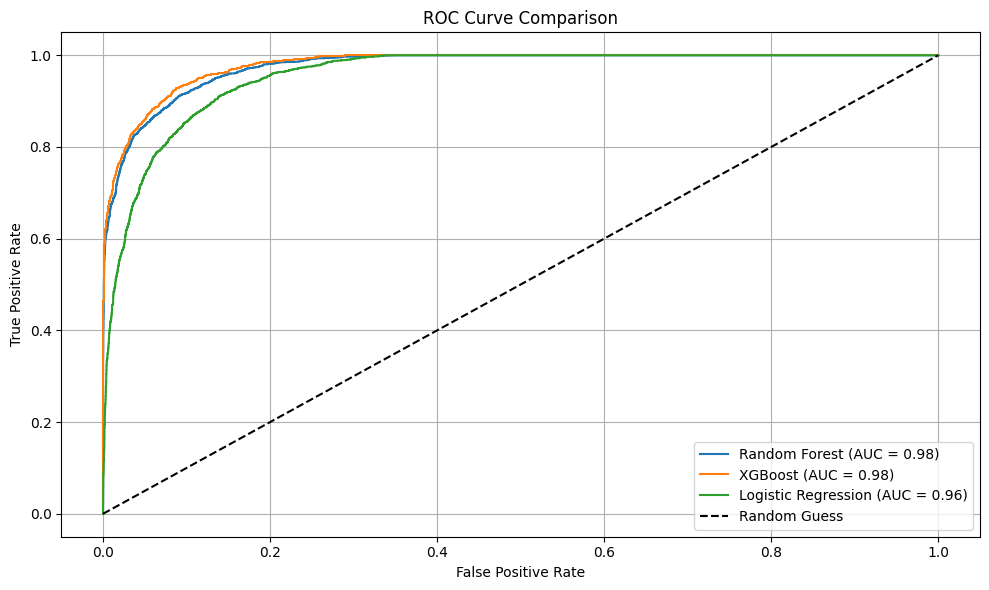

In [32]:
from sklearn.metrics import roc_curve, auc
plt.figure(figsize=(10, 6))
for name, model in models.items():
    y_proba=model.predict_proba(X_test)[:, 1]
    fpr,tpr,_=roc_curve(y_test, y_proba)
    roc_auc=auc(fpr,tpr)
    plt.plot(fpr,tpr,label=f'{name} (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

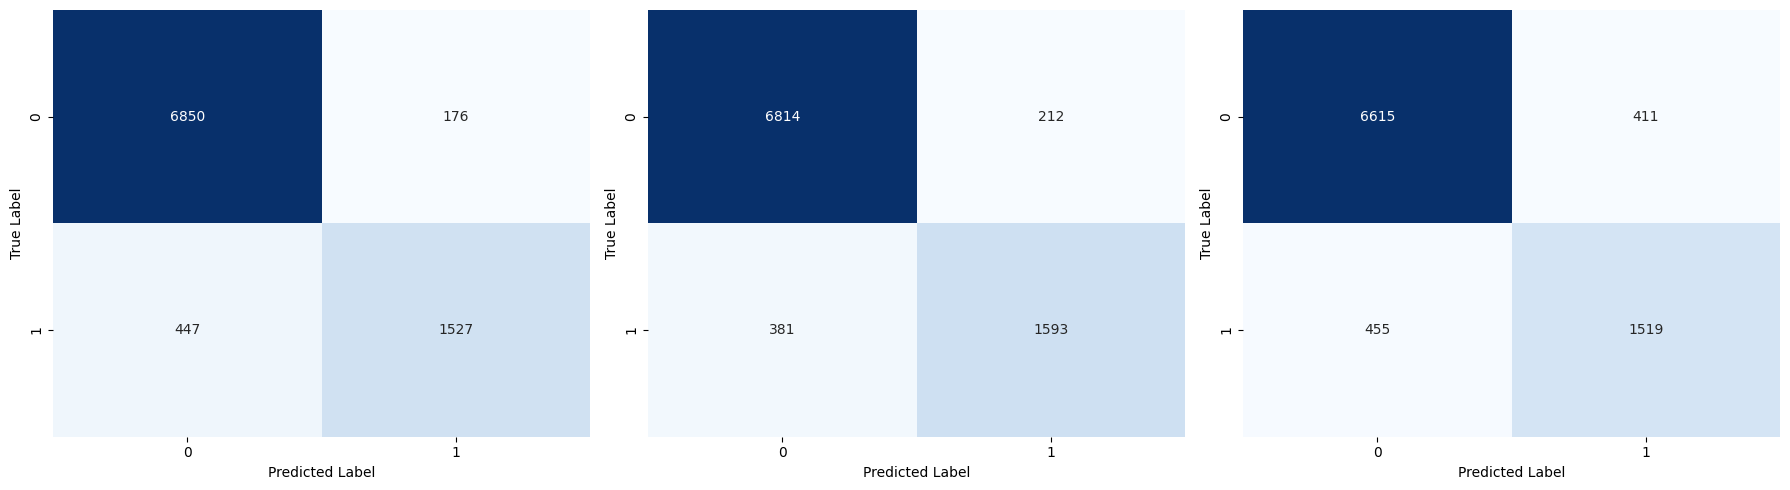

In [34]:
plt.figure(figsize=(18,5))
for i,(name,model) in enumerate(models.items(),1):
    y_pred=model.predict(X_test)
    cm=confusion_matrix(y_test,y_pred)
    plt.subplot(1,3,i)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',cbar=False)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")

plt.tight_layout()
plt.show()